In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import pandas as pd
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
    make_column_transformer,
)
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import make_scorer, root_mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
    RepeatedKFold,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

In [2]:
# Split into train and test
df = pd.read_csv("../Data/sales.csv")
df.head()

,type,likes,num_comments,num_shares,days_from_event,revenue,total_transactions,collab,date,num_posts,...,pop,popcorn_large,popcorn_medium,popcorn_small,Alcohol,general_promo_likes,general_promo_shares,type_post,candy,event_id
0,Regular screening,291.0,7.0,141.0,2.0,472.46,95.0,No,04/09/2025,1,...,17.0,7.0,11.0,5.0,0.0,NaN,NaN,individual,0.0,1
1,Regular screening,222.0,4.0,118.0,2.0,598.42,108.0,No,08/09/2025,1,...,19.0,9.0,17.0,12.0,0.0,NaN,NaN,individual,0.0,2
2,Regular screening,228.0,11.0,129.0,2.0,633.93,128.0,No,11/09/2025,1,...,26.0,20.0,21.0,8.0,0.0,NaN,NaN,individual,0.0,3
3,Screen + Q&A,137.0,0.0,39.0,10.0,25.00,9.0,No,15/09/2025,2,...,3.0,1.0,0.0,1.0,0.0,89.0,33.0,both,0.0,4
4,Regular screening,194.0,0.0,41.0,2.0,237.92,53.0,No,18/09/2025,2,...,19.0,6.0,6.0,9.0,0.0,89.0,33.0,both,0.0,5


In [3]:
# Fill missing values with 0
df["general_promo_likes"] = df["general_promo_likes"].fillna(0)
df["general_promo_shares"] = df["general_promo_shares"].fillna(0)

# Covert date from string
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Date/month feature
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

# Sort
df_sorted = df.sort_values("date")

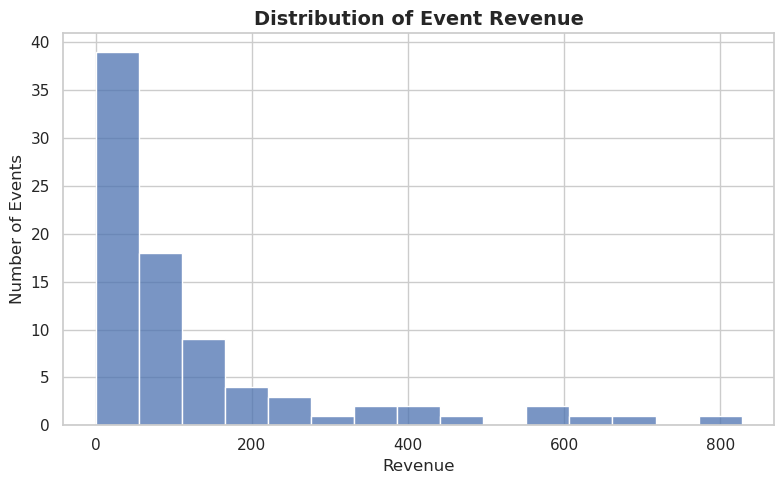

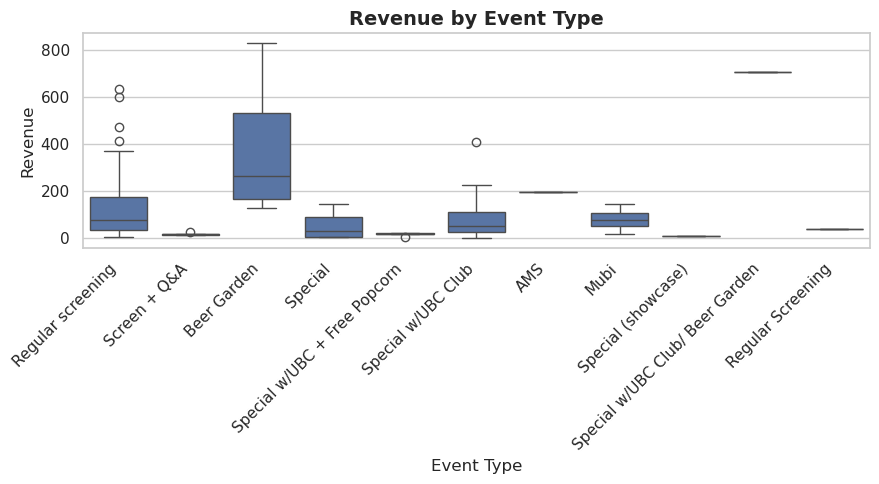

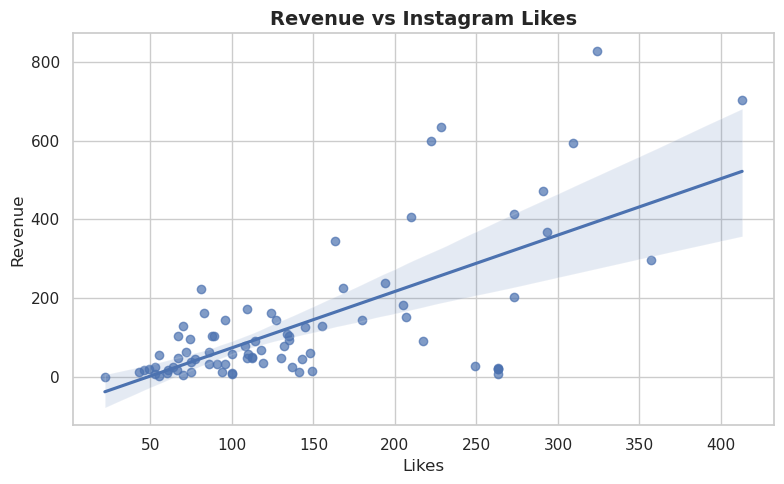

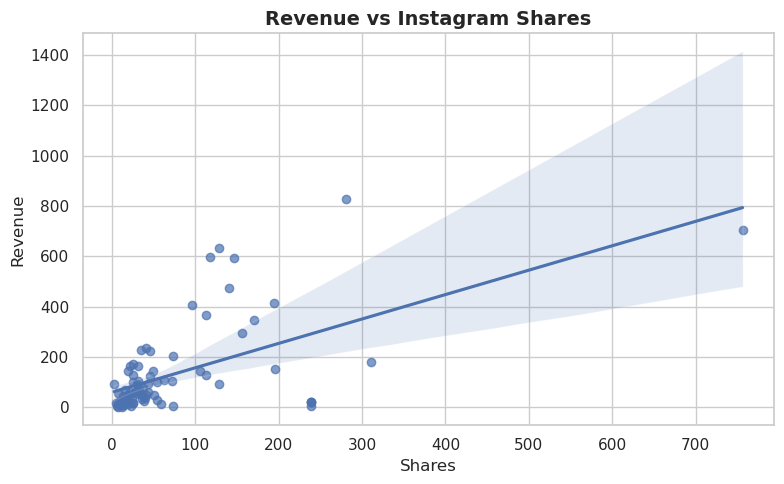

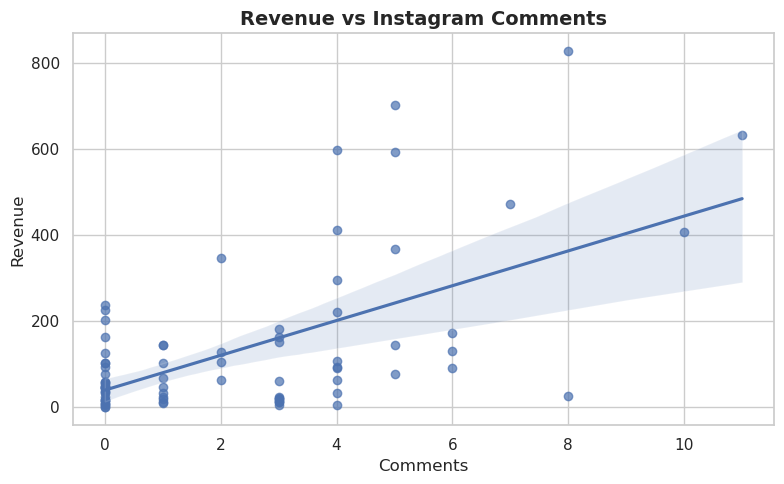

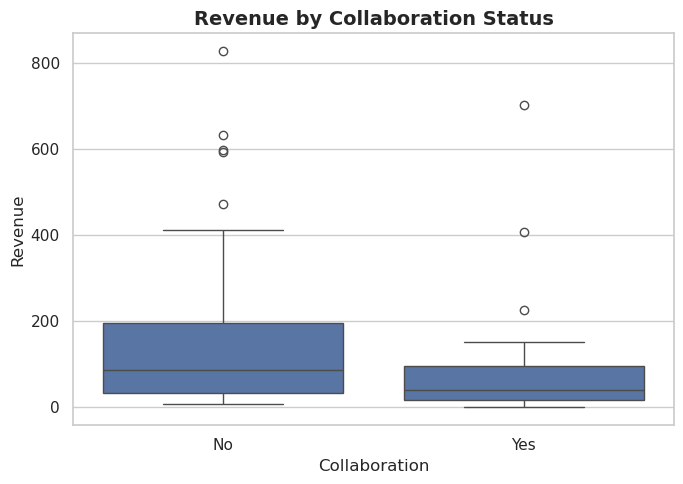

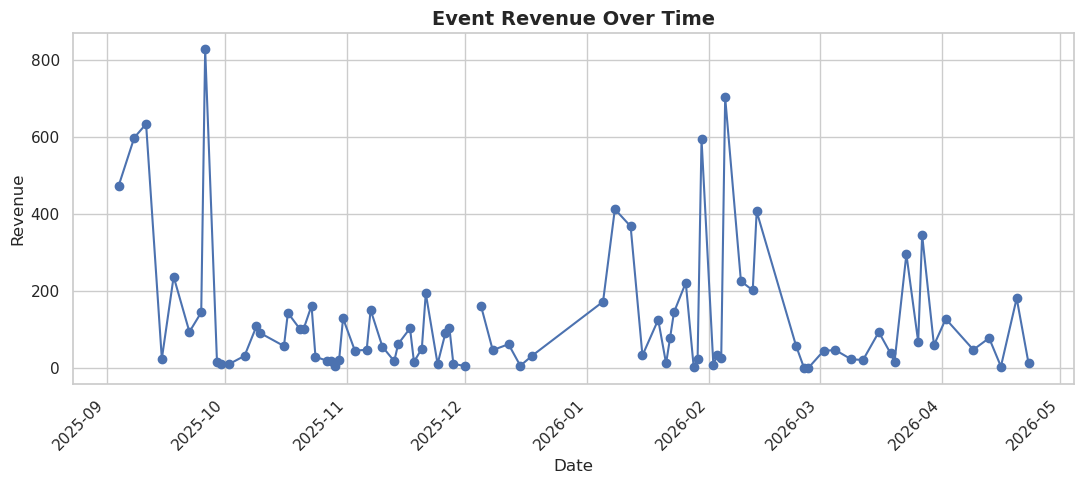

In [4]:
# EDA Visualizations
sns.set_theme(style="whitegrid")

def finish_plot(title, xlabel=None, ylabel=None, rotate_x=False):
    plt.title(title, fontsize=14, fontweight="bold")
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if rotate_x:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# 1. Revenue Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["revenue"], bins=15)
finish_plot(
    title="Distribution of Event Revenue",
    xlabel="Revenue",
    ylabel="Number of Events"
)


# 2. Revenue by Event Type
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="type", y="revenue")
finish_plot(
    title="Revenue by Event Type",
    xlabel="Event Type",
    ylabel="Revenue",
    rotate_x=True
)


# 3. Revenue vs Likes
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="likes", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Likes",
    xlabel="Likes",
    ylabel="Revenue"
)


# 4. Revenue vs Shares
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="num_shares", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Shares",
    xlabel="Shares",
    ylabel="Revenue"
)


# 5. Revenue vs Comments
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="num_comments", y="revenue", scatter_kws={"alpha": 0.7})
finish_plot(
    title="Revenue vs Instagram Comments",
    xlabel="Comments",
    ylabel="Revenue"
)


# 6. Revenue by Collaboration
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="collab", y="revenue")
finish_plot(
    title="Revenue by Collaboration Status",
    xlabel="Collaboration",
    ylabel="Revenue"
)


# 7. Revenue Over Time
plt.figure(figsize=(11, 5))
plt.plot(df_sorted["date"], df_sorted["revenue"], marker="o")
finish_plot(
    title="Event Revenue Over Time",
    xlabel="Date",
    ylabel="Revenue",
    rotate_x=True
)

<Axes: >

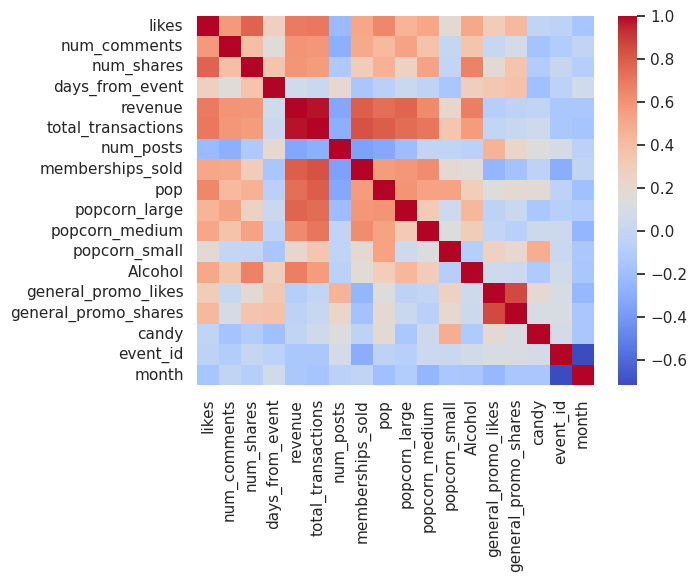

In [5]:
# Correlation mapping
numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

<Axes: xlabel='total_engagement', ylabel='revenue'>

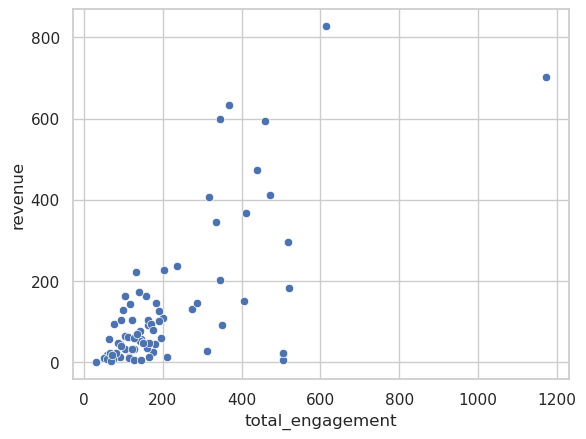

In [6]:
# Feature Engineering 
df["total_engagement"] = (
    df["likes"]
    + df["num_comments"]
    + df["num_shares"]
)

sns.scatterplot(
    data=df,
    x="total_engagement",
    y="revenue"
)

In [7]:
df = df.dropna(subset=["revenue"])

# Target
y = np.log1p(df["revenue"])

# Features
X = df.drop(columns=["revenue", "date", "event_id"])

In [8]:
numeric_features = [
    "likes",
    "num_comments",
    "num_shares",
    "num_posts",
    "days_from_event",
    "general_promo_likes",
    "general_promo_shares"
]

categorical_features = [
    "type",
    "collab",
    "month",
    "day_of_week"
]

numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)

In [10]:
# Dummy Model

dummy = make_pipeline(
    preprocessor,
    DummyRegressor(strategy="mean")
)

cross_val_score(
    dummy,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
).mean()

np.float64(-0.02493388608552145)

In [11]:
# Baseline: Linear Regression

ridge_model = make_pipeline(
    preprocessor,
    RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
)

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=123
)

ridge_cv_scores = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

print("RidgeCV CV R² scores:", ridge_cv_scores)
print("RidgeCV mean CV R²:", ridge_cv_scores.mean())
print("RidgeCV std CV R²:", ridge_cv_scores.std())

RidgeCV CV R² scores: [-0.012316    0.06164386  0.60678421  0.23437088  0.24514931  0.31424782
  0.49441206  0.09868753  0.28010344  0.30591578 -1.12481312  0.12884868
  0.3327909   0.38720346  0.47185752 -1.30373962  0.40013476  0.53998739
  0.2760708   0.05936844  0.47471835  0.37216372  0.52587568  0.42937584
  0.28835263 -0.27836709  0.30286642  0.67547054  0.2961938   0.46507533
  0.08355486 -0.44251613  0.49589811  0.67835109 -0.40579617  0.58486012
  0.22541656  0.08545388  0.47982171  0.15964597  0.73102929 -0.14186796
  0.46493405  0.26117765  0.02702605  0.41029337  0.14678222  0.43816283
  0.31621906 -0.68068198]
RidgeCV mean CV R²: 0.20532395760944194
RidgeCV std CV R²: 0.4062571791590481


In [12]:
ridge_model.fit(X_train, y_train)

preds_log = ridge_model.predict(X_test)

actual_revenue = np.expm1(y_test)
predicted_revenue = np.expm1(preds_log)

print(
    "RidgeCV Test RMSE:",
    root_mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

print(
    "RidgeCV Test R²:",
    r2_score(
        actual_revenue,
        predicted_revenue
    )
)

RidgeCV Test RMSE: 104.55438349524118
RidgeCV Test R²: 0.481806690927715


In [13]:
# Random Forest
rf_model = make_pipeline(
    preprocessor,
    RandomForestRegressor(
        n_estimators=500,
        random_state=123
    )
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

print("RF CV R² Scores:")
print(rf_cv_scores)

print("\nMean CV R²:")
print(rf_cv_scores.mean())

print("\nStd CV R²:")
print(rf_cv_scores.std())

RF CV R² Scores:
[-0.34293056 -0.27442986  0.60757349  0.31663794  0.43878075  0.39279617
  0.49304839  0.50276457  0.15014781  0.51184896 -1.36158347 -0.12342836
  0.45076752  0.39625247  0.48927495 -1.71483796  0.05977055  0.21488438
  0.37059631  0.4321009   0.57702968  0.39181981  0.45618212  0.09476945
  0.60594989 -0.08921248  0.33854854  0.39840053  0.11573329  0.41253882
  0.0763494   0.12459265  0.4753794   0.65213516 -0.0490616   0.58244122
  0.39538893  0.20817402  0.3520625   0.06791158  0.49377923  0.14599729
  0.56823224  0.51214194  0.06454206  0.56228977  0.28094218  0.3577764
  0.39837428  0.1739355 ]

Mean CV R²:
0.2351035753142871

Std CV R²:
0.43020262869324016


In [14]:
rf_model.fit(X_train, y_train)

rf_preds_log = rf_model.predict(X_test)

actual_revenue = np.expm1(y_test)
predicted_revenue = np.expm1(rf_preds_log)

print(
    "RF Test RMSE:",
    root_mean_squared_error(
        actual_revenue,
        predicted_revenue
    )
)

print(
    "RF Test R²:",
    r2_score(
        actual_revenue,
        predicted_revenue
    )
)

RF Test RMSE: 92.5015985577284
RF Test R²: 0.5943926782304638


In [15]:
# Comparison
results = pd.DataFrame({
    "Model": ["RidgeCV", "Random Forest"],
    "CV R²": [
        ridge_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "CV Std": [
        ridge_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

results

,Model,CV R²,CV Std
0,RidgeCV,0.205324,0.406257
1,Random Forest,0.235104,0.430203


In [16]:
# Feature Importances 
rf_model.fit(X_train, y_train)

result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=123,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
1,likes,0.254151
3,num_shares,0.119182
2,num_comments,0.057313
19,day_of_week,0.035325
14,general_promo_likes,0.018792
0,type,0.014943
4,days_from_event,0.013394
15,general_promo_shares,0.009985
6,collab,0.001433
11,popcorn_medium,0.000000


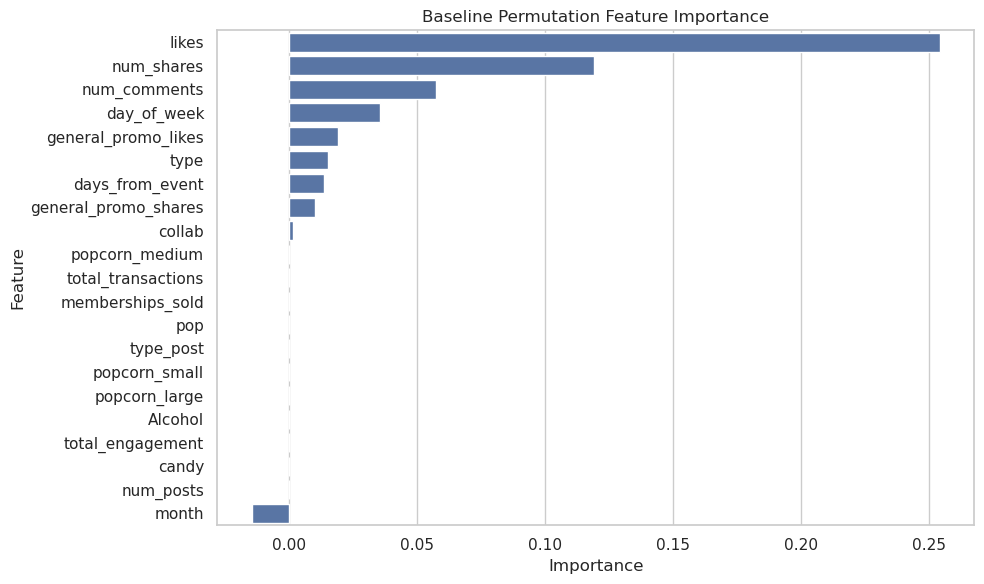

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)
plt.title("Baseline Permutation Feature Importance")
plt.tight_layout()
plt.show()

# Movie Ratings Analysis

In [18]:
events = pd.read_csv("../Data/sales.csv")
movies = pd.read_csv("../Data/movie.csv")

events = events.reset_index(drop=True)
events["event_id"] = events.index + 1

# Rename columns
movies = movies.rename(columns={
    "movie_1_ratings": "movie_1_review_count",
    "movie_2_ratings": "movie_2_review_count",
    "movie_1_release": "movie_1_release_year",
    "movie_2_release": "movie_2_release_year"
})

df_enriched = events.merge(
    movies,
    on="event_id",
    how="left"
)

df_enriched.head()

,type,likes,num_comments,num_shares,days_from_event,revenue,total_transactions,collab,date,num_posts,...,movie_1_title,movie_2_title,movie_1_rating,movie_2_rating,movie_1_review_count,movie_2_review_count,movie_1_genre,movie_2_genre,movie_1_release_year,movie_2_release_year
0,Regular screening,291.0,7.0,141.0,2.0,472.46,95.0,No,04/09/2025,1,...,Perks of Being a Wallflower,Welcome to The Dollhouse,4.0,3.6,635996.0,37579.0,Drama,Comedy/Drama,2012.0,1995.0
1,Regular screening,222.0,4.0,118.0,2.0,598.42,108.0,No,08/09/2025,1,...,Mean Girls,Jawbreaker,3.8,3.4,401508.0,47246.0,Comedy/Drama,Comedy/Thriller,2004.0,1999.0
2,Regular screening,228.0,11.0,129.0,2.0,633.93,128.0,No,11/09/2025,1,...,American Psycho,Rules of Attraction,3.8,3.3,555179.0,12652.0,Crime/Drama/Thriller,Comedy/Drama,2000.0,2002.0
3,Screen + Q&A,137.0,0.0,39.0,10.0,25.00,9.0,No,15/09/2025,2,...,Golden Gate Girls,NaN,3.5,NaN,67.0,NaN,Documentry,NaN,2013.0,NaN
4,Regular screening,194.0,0.0,41.0,2.0,237.92,53.0,No,18/09/2025,2,...,Mallrats,SLC Punk,3.4,3.8,23687.0,55648.0,Romance/Comedy,Comedy/Drama,1995.0,1998.0


In [19]:
# Drop rows where target is missing
df_enriched = df_enriched.dropna(subset=["revenue"]).copy()

# Convert date
df_enriched["date"] = pd.to_datetime(
    df_enriched["date"],
    dayfirst=True
)

# Clean text columns
text_cols = [
    "movie_1_title",
    "movie_2_title",
    "movie_1_genre",
    "movie_2_genre",
    "type",
    "collab",
    "type_post"
]

for col in text_cols:
    df_enriched[col] = (
        df_enriched[col]
        .astype("string")
        .str.strip()
    )

# Fix typo
df_enriched["movie_1_genre"] = df_enriched["movie_1_genre"].replace(
    {"Documentry": "Documentary"}
)
df_enriched["movie_2_genre"] = df_enriched["movie_2_genre"].replace(
    {"Documentry": "Documentary"}
)

In [20]:
# Number of movies shown
df_enriched["num_movies"] = df_enriched[
    ["movie_1_title", "movie_2_title"]
].notna().sum(axis=1)

df_enriched["double_feature"] = (
    df_enriched["num_movies"] == 2
).astype(int)

# Ratings
df_enriched["avg_movie_rating"] = df_enriched[
    ["movie_1_rating", "movie_2_rating"]
].mean(axis=1)

df_enriched["max_movie_rating"] = df_enriched[
    ["movie_1_rating", "movie_2_rating"]
].max(axis=1)

# Review counts / popularity
df_enriched["total_review_count"] = df_enriched[
    ["movie_1_review_count", "movie_2_review_count"]
].sum(axis=1, min_count=1)

df_enriched["max_review_count"] = df_enriched[
    ["movie_1_review_count", "movie_2_review_count"]
].max(axis=1)

# Release year
df_enriched["avg_release_year"] = df_enriched[
    ["movie_1_release_year", "movie_2_release_year"]
].mean(axis=1)

df_enriched["oldest_release_year"] = df_enriched[
    ["movie_1_release_year", "movie_2_release_year"]
].min(axis=1)

# Movie age at event
df_enriched["event_year"] = df_enriched["date"].dt.year
df_enriched["avg_movie_age"] = (
    df_enriched["event_year"] - df_enriched["avg_release_year"]
)

# Primary genre = first listed genre of movie 1
df_enriched["primary_genre"] = (
    df_enriched["movie_1_genre"]
    .str.split("/")
    .str[0]
    .str.strip()
)

In [21]:
df_enriched["popularity_bucket"] = pd.qcut(
    df_enriched["max_review_count"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

In [22]:
df_enriched[
    [
        "revenue",
        "movie_1_title",
        "movie_2_title",
        "avg_movie_rating",
        "max_review_count",
        "total_review_count",
        "primary_genre",
        "num_movies",
        "double_feature"
    ]
].head()

,revenue,movie_1_title,movie_2_title,avg_movie_rating,max_review_count,total_review_count,primary_genre,num_movies,double_feature
0,472.46,Perks of Being a Wallflower,Welcome to The Dollhouse,3.80,635996.0,673575.0,Drama,2,1
1,598.42,Mean Girls,Jawbreaker,3.60,401508.0,448754.0,Comedy,2,1
2,633.93,American Psycho,Rules of Attraction,3.55,555179.0,567831.0,Crime,2,1
3,25.00,Golden Gate Girls,<NA>,3.50,67.0,67.0,Documentary,1,0
4,237.92,Mallrats,SLC Punk,3.60,55648.0,79335.0,Romance,2,1


In [23]:
df_enriched[
    [
        "avg_movie_rating",
        "max_review_count",
        "total_review_count",
        "avg_movie_age",
        "primary_genre"
    ]
].isna().sum()

avg_movie_rating      5
max_review_count      5
total_review_count    5
avg_movie_age         4
primary_genre         5
dtype: int64

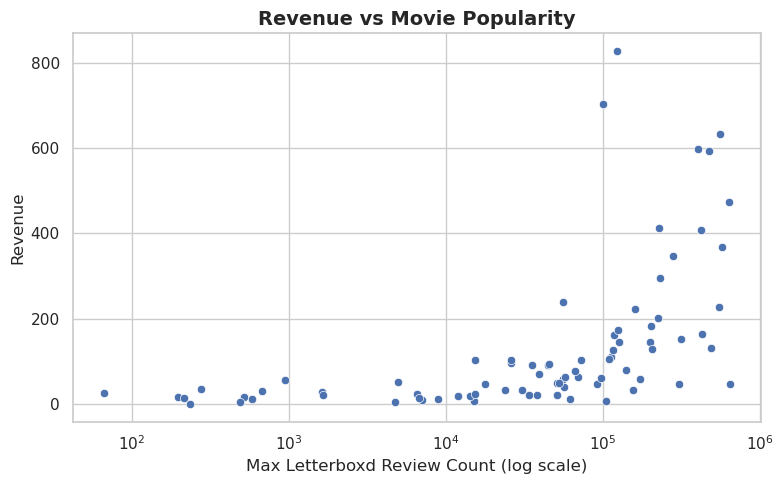

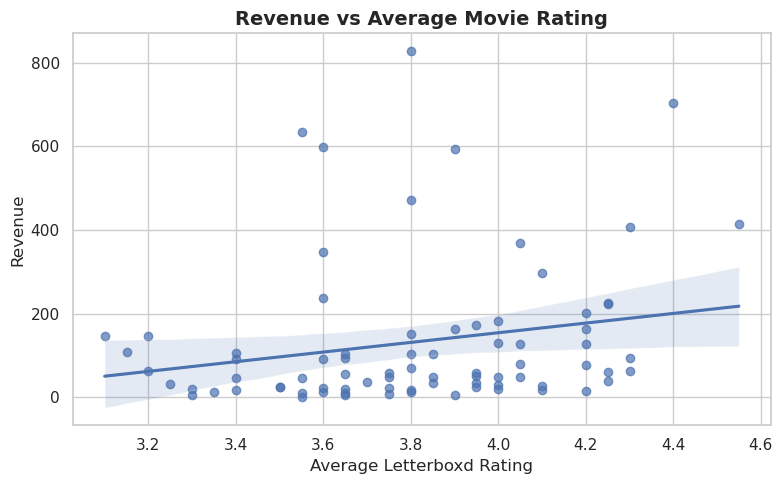

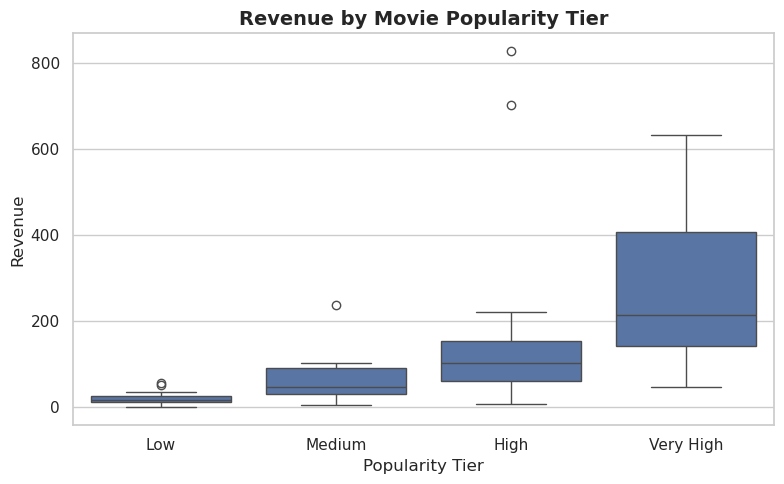

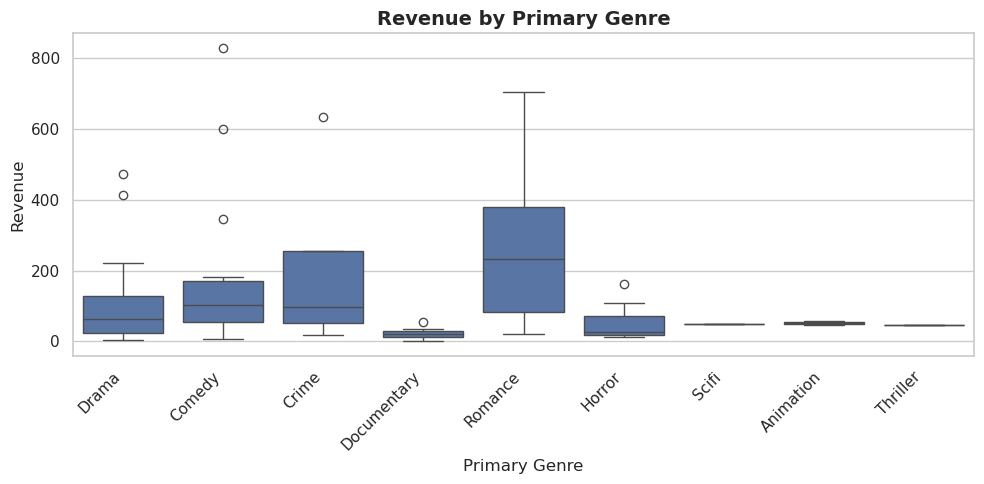

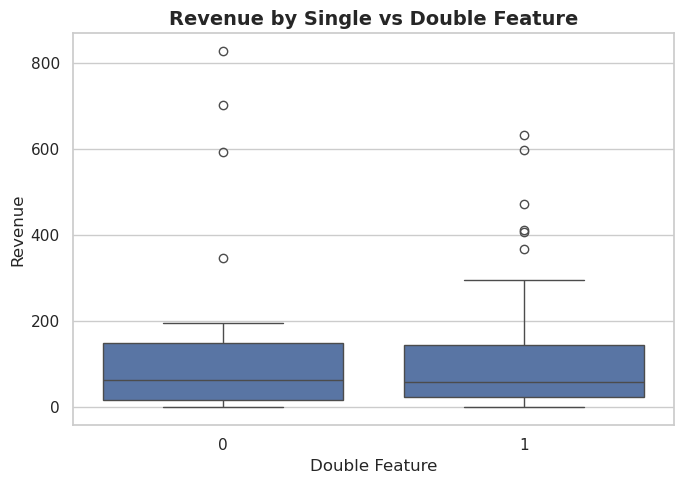

In [24]:
def finish_plot(title, xlabel=None, ylabel=None, rotate_x=False):
    plt.title(title, fontsize=14, fontweight="bold")
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if rotate_x:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Revenue vs Movie popularity
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_enriched,
    x="max_review_count",
    y="revenue"
)
plt.xscale("log")
finish_plot(
    "Revenue vs Movie Popularity",
    "Max Letterboxd Review Count (log scale)",
    "Revenue"
)

# Revenue vs Movie rating 
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_enriched,
    x="avg_movie_rating",
    y="revenue",
    scatter_kws={"alpha": 0.7}
)
finish_plot(
    "Revenue vs Average Movie Rating",
    "Average Letterboxd Rating",
    "Revenue"
)

# Revenue by popularity bucket
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_enriched,
    x="popularity_bucket",
    y="revenue"
)
finish_plot(
    "Revenue by Movie Popularity Tier",
    "Popularity Tier",
    "Revenue"
)

# Revenue by genre
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_enriched,
    x="primary_genre",
    y="revenue"
)
finish_plot(
    "Revenue by Primary Genre",
    "Primary Genre",
    "Revenue",
    rotate_x=True
)

# Revenue by double feature
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_enriched,
    x="double_feature",
    y="revenue"
)
finish_plot(
    "Revenue by Single vs Double Feature",
    "Double Feature",
    "Revenue"
)

# Model Version 2

In [25]:
df_enriched["log_max_review_count"] = np.log1p(
    df_enriched["max_review_count"]
)

df_enriched["log_total_review_count"] = np.log1p(
    df_enriched["total_review_count"]
)

# Make sure date is datetime
df_enriched["date"] = pd.to_datetime(df_enriched["date"], dayfirst=True)

# Date features
df_enriched["month"] = df_enriched["date"].dt.month
df_enriched["day_of_week"] = df_enriched["date"].dt.day_name()

# Engagement features
df_enriched["total_engagement"] = (
    df_enriched["likes"]
    + df_enriched["num_comments"]
    + df_enriched["num_shares"]
)

df_enriched["engagement_per_post"] = (
    df_enriched["total_engagement"] / df_enriched["num_posts"]
)

df_enriched["engagement_per_post"] = df_enriched[
    "engagement_per_post"
].replace([np.inf, -np.inf], np.nan)

In [26]:
baseline_numeric_features = [
    "likes",
    "num_comments",
    "num_shares",
    "num_posts",
    "days_from_event",
    "general_promo_likes",
    "general_promo_shares",
    "total_engagement",
    "engagement_per_post",
    "month"
]

baseline_categorical_features = [
    "type",
    "collab",
    "day_of_week"
]

movie_numeric_features = [
    "avg_movie_rating",
    "log_max_review_count",
    "log_total_review_count",
    "avg_movie_age",
    "double_feature"
]

movie_categorical_features = [
    "primary_genre"
]

combined_numeric_features = (
    baseline_numeric_features
    + movie_numeric_features
)

combined_categorical_features = (
    baseline_categorical_features
    + movie_categorical_features
)

In [27]:
# Replace pandas pd.NA with numpy np.nan for sklearn compatibility
df_enriched = df_enriched.replace({pd.NA: np.nan})

# Make categorical columns sklearn-friendly
all_categorical_features = list(
    set(
        baseline_categorical_features
        + movie_categorical_features
        + combined_categorical_features
    )
)

for col in all_categorical_features:
    df_enriched[col] = df_enriched[col].astype(object)
    
y = np.log1p(df_enriched["revenue"])

X_baseline = df_enriched[
    baseline_numeric_features + baseline_categorical_features
]

X_movie = df_enriched[
    movie_numeric_features + movie_categorical_features
]

X_combined = df_enriched[
    combined_numeric_features + combined_categorical_features
]

In [28]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler()
    )

    categorical_transformer = make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    )

    return ColumnTransformer(
        [
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

def evaluate_model(
    model,
    X,
    y,
    numeric_features,
    categorical_features,
    model_name,
    feature_set_name
):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=123
    )

    preprocessor = build_preprocessor(
        numeric_features,
        categorical_features
    )

    pipeline = make_pipeline(
        preprocessor,
        model
    )

    cv = RepeatedKFold(
        n_splits=5,
        n_repeats=10,
        random_state=123
    )

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    pipeline.fit(X_train, y_train)

    preds_log = pipeline.predict(X_test)

    actual_revenue = np.expm1(y_test)
    predicted_revenue = np.expm1(preds_log)

    return {
        "Feature Set": feature_set_name,
        "Model": model_name,
        "Mean CV R²": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Test RMSE": root_mean_squared_error(
            actual_revenue,
            predicted_revenue
        ),
        "Test R²": r2_score(
            actual_revenue,
            predicted_revenue
        ),
        "Pipeline": pipeline,
        "X_test": X_test,
        "y_test": y_test
    }

In [29]:
experiments = []

feature_sets = [
    (
        "Baseline: Event + Instagram",
        X_baseline,
        baseline_numeric_features,
        baseline_categorical_features
    ),
    (
        "Movie Features Only",
        X_movie,
        movie_numeric_features,
        movie_categorical_features
    ),
    (
        "Combined: Instagram + Movie",
        X_combined,
        combined_numeric_features,
        combined_categorical_features
    )
]

for feature_set_name, X_data, num_feats, cat_feats in feature_sets:

    experiments.append(
        evaluate_model(
            DummyRegressor(strategy="mean"),
            X_data,
            y,
            num_feats,
            cat_feats,
            "Dummy",
            feature_set_name
        )
    )

    experiments.append(
        evaluate_model(
            RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
            X_data,
            y,
            num_feats,
            cat_feats,
            "RidgeCV",
            feature_set_name
        )
    )

    experiments.append(
        evaluate_model(
            RandomForestRegressor(
                n_estimators=500,
                max_depth=10,
                min_samples_leaf=3,
                random_state=123
            ),
            X_data,
            y,
            num_feats,
            cat_feats,
            "Random Forest",
            feature_set_name
        )
    )

In [30]:
results = pd.DataFrame(experiments)

results_display = results.drop(
    columns=["Pipeline", "X_test", "y_test"]
)

results_display.sort_values(
    by="Mean CV R²",
    ascending=False
)

,Feature Set,Model,Mean CV R²,CV Std,Test RMSE,Test R²
7,Combined: Instagram + Movie,RidgeCV,0.354067,0.373342,96.706461,0.556679
8,Combined: Instagram + Movie,Random Forest,0.348796,0.316191,91.003251,0.607426
4,Movie Features Only,RidgeCV,0.297766,0.262033,109.494469,0.431682
5,Movie Features Only,Random Forest,0.204957,0.380105,109.380871,0.432860
2,Baseline: Event + Instagram,Random Forest,0.179251,0.453591,120.231601,0.314757
1,Baseline: Event + Instagram,RidgeCV,0.122737,0.555147,86.932766,0.641760
0,Baseline: Event + Instagram,Dummy,-0.116056,0.164811,166.121383,-0.308153
3,Movie Features Only,Dummy,-0.116056,0.164811,166.121383,-0.308153
6,Combined: Instagram + Movie,Dummy,-0.116056,0.164811,166.121383,-0.308153


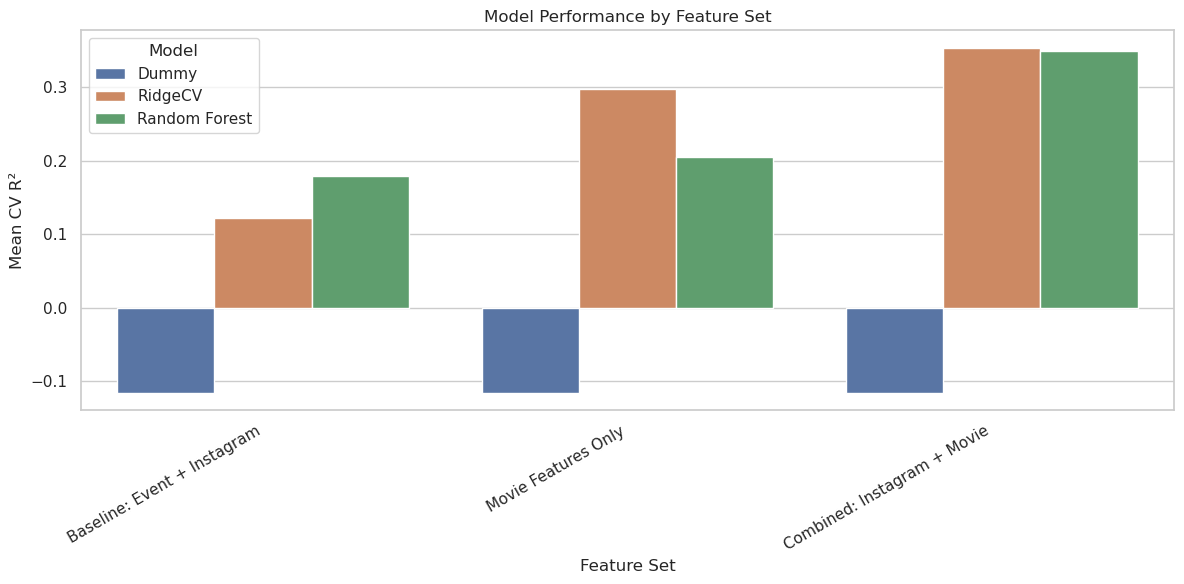

In [31]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_display,
    x="Feature Set",
    y="Mean CV R²",
    hue="Model"
)

plt.title("Model Performance by Feature Set")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [32]:
best_result = results[
    (results["Feature Set"] == "Combined: Instagram + Movie")
    & (results["Model"] == "Random Forest")
].iloc[0]

best_pipeline = best_result["Pipeline"]
best_X_test = best_result["X_test"]
best_y_test = best_result["y_test"]

In [33]:
perm = permutation_importance(
    best_pipeline,
    best_X_test,
    best_y_test,
    n_repeats=30,
    random_state=123,
    scoring="r2"
)

feature_names = best_X_test.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
11,log_max_review_count,0.286601
2,num_shares,0.067820
0,likes,0.050245
12,log_total_review_count,0.042197
6,general_promo_shares,0.013654
9,month,0.009200
1,num_comments,0.008633
18,primary_genre,0.006906
7,total_engagement,0.005219
8,engagement_per_post,0.004620


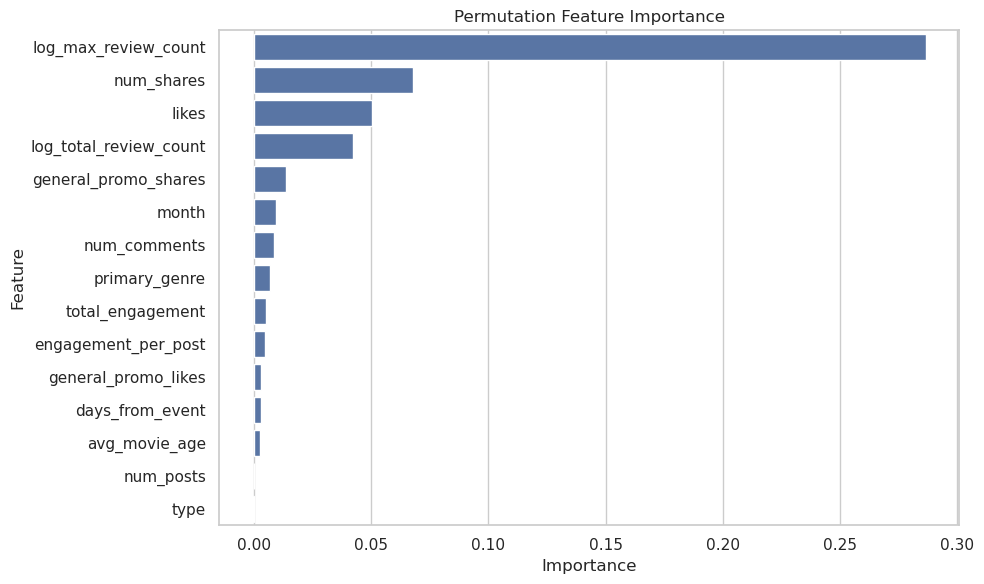

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()